# Primeros grafiquitos  — AlertaSegura Perú

Sprint 3 · Data Analysis

Usa el dataset sintético ya más realista (220 reportes, con patrones de
categoría-por-distrito y "hotspots" de problemas recurrentes en vez de
distribución puramente uniforme). Genera las gráficas principales:
reportes por distrito y reportes por tipo de incidente.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

reportes = pd.read_csv("../data/reportes_sinteticos.csv", parse_dates=["created_at"])
print("Total de reportes:", len(reportes))
reportes.head()

Total de reportes: 220


,id,usuario_id,categoria,descripcion,latitud,longitud,distrito,estado,created_at
0,1,35,Robo,Sustracción de autopartes en la cuadra,-12.222534,-76.940923,Villa El Salvador,RECHAZADO,2026-07-04 00:30:00
1,2,15,Bache,Pista deteriorada genera accidentes,-12.170940,-77.021719,Chorrillos,VERIFICADO,2026-06-03 19:59:00
2,3,6,Alumbrado deficiente,Poste sin luz hace varias semanas,-12.166607,-76.941017,Villa María del Triunfo,VERIFICADO,2026-06-30 00:15:00
3,4,1,Robo,Sustrajeron mi celular en la calle,-12.220713,-76.940200,Villa El Salvador,PENDIENTE,2026-05-18 22:06:00
4,5,12,Acoso,Acoso a estudiantes cerca del colegio,-12.072284,-77.011307,La Victoria,PENDIENTE,2026-07-03 23:25:00


## Reportes por distrito

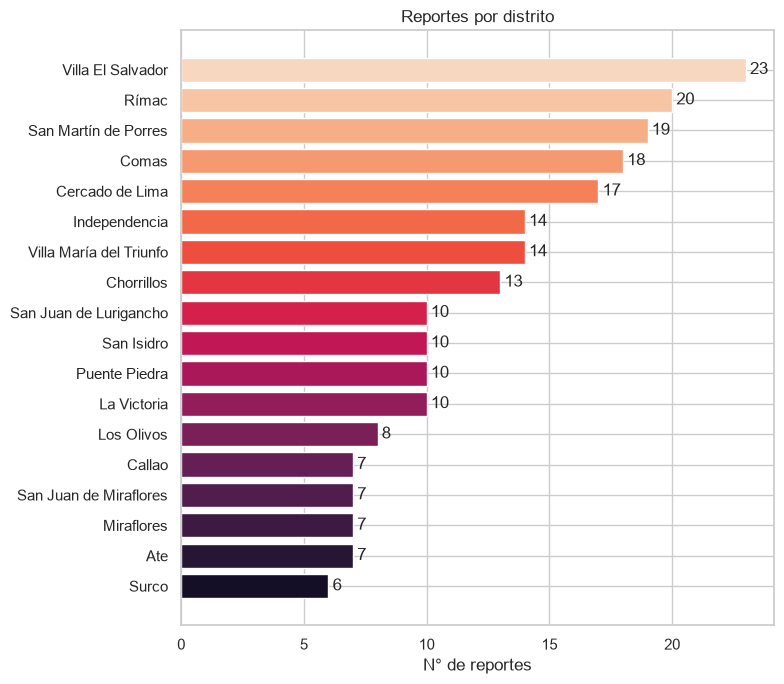

In [6]:
conteo_distrito = reportes["distrito"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(conteo_distrito.index, conteo_distrito.values, color=sns.color_palette("rocket", len(conteo_distrito)))
ax.bar_label(bars, padding=3)
ax.set_title("Reportes por distrito")
ax.set_xlabel("N° de reportes")
plt.tight_layout()
plt.show()

## Reportes por tipo de incidente

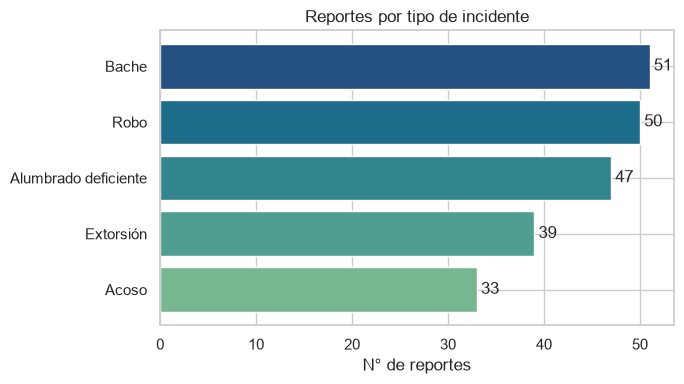

In [7]:
conteo_categoria = reportes["categoria"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(conteo_categoria.index, conteo_categoria.values, color=sns.color_palette("crest", len(conteo_categoria)))
ax.bar_label(bars, padding=3)
ax.set_title("Reportes por tipo de incidente")
ax.set_xlabel("N° de reportes")
plt.tight_layout()
plt.show()

## Categoría × distrito

Con más registros ya se nota que las categorías no se distribuyen igual
en todos los distritos: hay concentraciones puntuales ("hotspots") que
van a ser el insumo para el modelo de zonas de riesgo del Sprint 4.

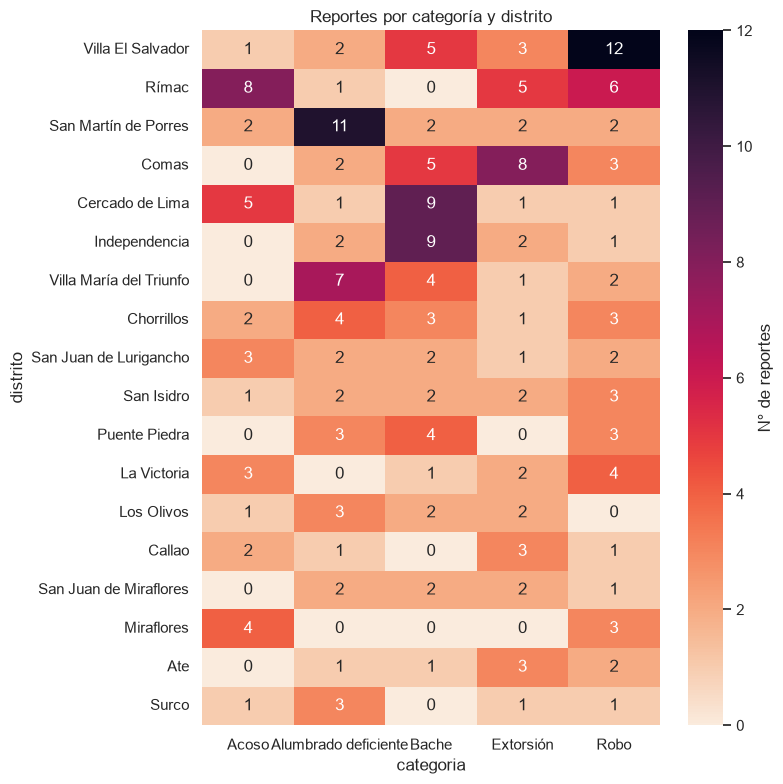

In [8]:
tabla = pd.crosstab(reportes["distrito"], reportes["categoria"])
tabla = tabla.loc[conteo_distrito.index[::-1]]  # mismo orden que el gráfico de arriba

plt.figure(figsize=(8, 8))
sns.heatmap(tabla, annot=True, fmt="d", cmap="rocket_r", cbar_kws={"label": "N° de reportes"})
plt.title("Reportes por categoría y distrito")
plt.tight_layout()
plt.show()

## Próximos pasos (Sprint 4)

- Modelo de zonas de riesgo (KMeans o heatmap geográfico) sobre estos datos.
- Dashboard interactivo (Plotly/Dash) con los hallazgos principales.